In this example, we demostrate how to get a skyrmion using MicroMagnetic.jl. We use the parameters given in PRL **111** 067203 (2013).

> **Used parameters in the simulation**
>
> |Parameter | Value  |
> | :----:   | :----: |
> | Lattice constant | $a = 0.5$ nm |
> | Spin length      | $S = 1$      |
> | Magnetic moment  |  $\mu_s = 2 \mu_B$ |
> | Excahnge constant |  $J = 50 k_B$   |
> | DMI         | $D/J = 0.5$  |     |
> | External field  | $H \mu_s /J  = 0.2$ |

In [1]:
using MicroMagnetic
using CairoMakie

mesh = CubicMesh(; nx=50, ny=50, nz=1, pbc="xy")

function m0_fun(i, j, k, dx, dy, dz)
    r2 = (i - 25)^2 + (j - 25)^2
    if r2 < 10^2
        return (0.01, 0, -1)
    end
    return (0, 0, 1)
end

m0_fun (generic function with 1 method)

We define a function to specify the problem.

In [2]:
function relax_system()
    #We create a simulation with 'SD' driver
    sim = Sim(mesh; driver="SD", name="skx")

    set_mu_s(sim, mu_s_1) # set mu_s of the system

    #Initialize the system using the `m0_fun` function
    init_m0(sim, m0_fun)

    J = 50 * k_B
    add_exch(sim, J; name="exch")
    add_dmi(sim, 0.5 * J; name="dmi")

    Hz = 0.2 * J / mu_s_1
    add_zeeman(sim, (0, 0, Hz)) # the unit of Hz is Tesla

    #Relax the system
    relax(sim; max_steps=2000, stopping_dmdt=0.01)

    #Save the magnetization to vtk file
    save_vtk(sim, "skx"; fields=["exch", "dmi"])

    return sim
end

sim = relax_system();

[ Info: AtomisticSim has been created.
[ Info: Bulk DMI for CubicMesh has been added!
[ Info: Static Zeeman has been added.
[ Info: Running Driver : MicroMagnetic.EnergyMinimization{Float64}.
[ Info: max_dmdt is less than stopping_dmdt=0.01 @steps=39, Done!


After obtain the skyrmion, we use the following script to plot the skyrmion

┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/aJUtI/src/basic_recipes/arrows.jl:166


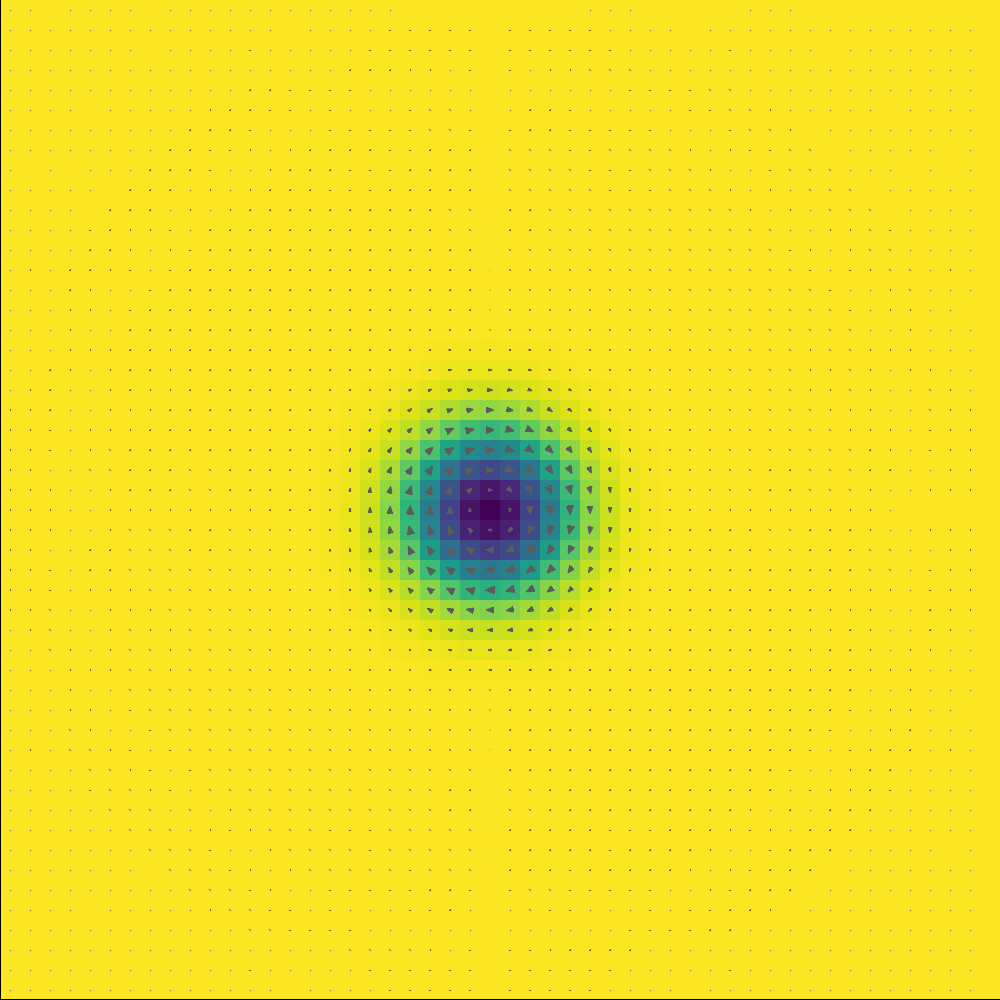

In [3]:
plot_m(sim)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*